# Greek Electricity Demand — Exploratory Data Analysis

Exploring ~6.5 years of hourly electricity demand data for Greece (2020–2026), 
combined with weather data from 5 major cities.

**Data sources:**
- ENTSO-E Transparency Platform — actual load & day-ahead forecast
- Open-Meteo API — temperature, humidity, solar radiation, wind, precipitation

**Goals of this EDA:**
1. Understand demand patterns (daily, weekly, yearly)
2. Quantify the weather–demand relationship
3. Assess the ENTSO-E day-ahead forecast as benchmark
4. Identify anomalies and structural changes (COVID, energy crisis)
5. Inform feature engineering decisions


## 1. Data Overview

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

df = pd.read_parquet("../data/processed/dataset.parquet")

print(f"Shape: {df.shape}")
print(f"Period: {df.timestamp.min()} to {df.timestamp.max()}")
print(f"Nulls:\n{df.isnull().sum()}")
df.head()

Shape: (58728, 8)
Period: 2020-01-01 00:00:00+00:00 to 2026-09-12 23:00:00+00:00
Nulls:
timestamp                0
actual_load_mw           0
forecast_load_mw        22
temperature_c            0
humidity_pct             0
solar_radiation_w_m2     0
wind_speed_kmh           0
precipitation_mm         0
dtype: int64


,timestamp,actual_load_mw,forecast_load_mw,temperature_c,humidity_pct,solar_radiation_w_m2,wind_speed_kmh,precipitation_mm
0,2020-01-01 00:00:00+00:00,5219.17,5399.10,3.81,70.0,0.0,8.68,0.04
1,2020-01-01 01:00:00+00:00,4910.21,5118.40,3.93,66.6,0.0,9.00,0.07
2,2020-01-01 02:00:00+00:00,4677.46,4897.64,3.66,65.6,0.0,9.30,0.06
3,2020-01-01 03:00:00+00:00,4571.97,4796.98,3.97,62.7,0.0,11.01,0.09
4,2020-01-01 04:00:00+00:00,4629.67,4816.58,4.02,61.6,0.0,12.26,0.08


## 2. Demand Over Time — The Big Picture

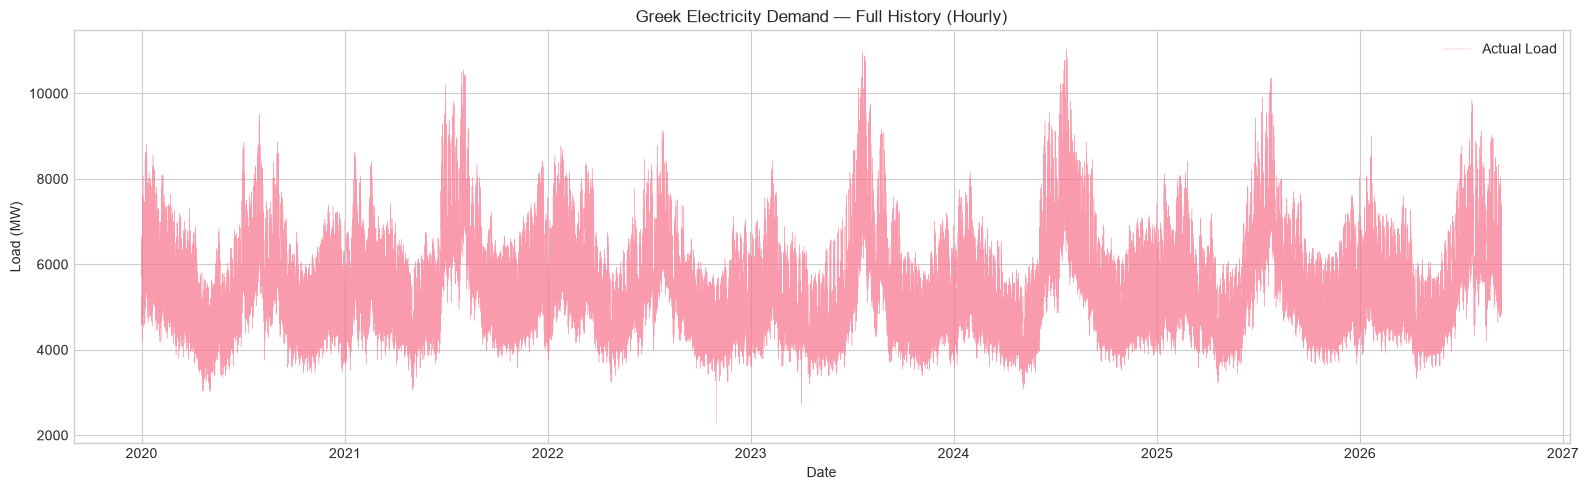

In [3]:
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(df.timestamp, df.actual_load_mw, linewidth=0.3, alpha=0.7, label="Actual Load")
ax.set_xlabel("Date")
ax.set_ylabel("Load (MW)")
ax.set_title("Greek Electricity Demand — Full History (Hourly)")
ax.legend()

plt.tight_layout()
plt.show()

## 3. Yearly Comparison — Is there a COVID effect?

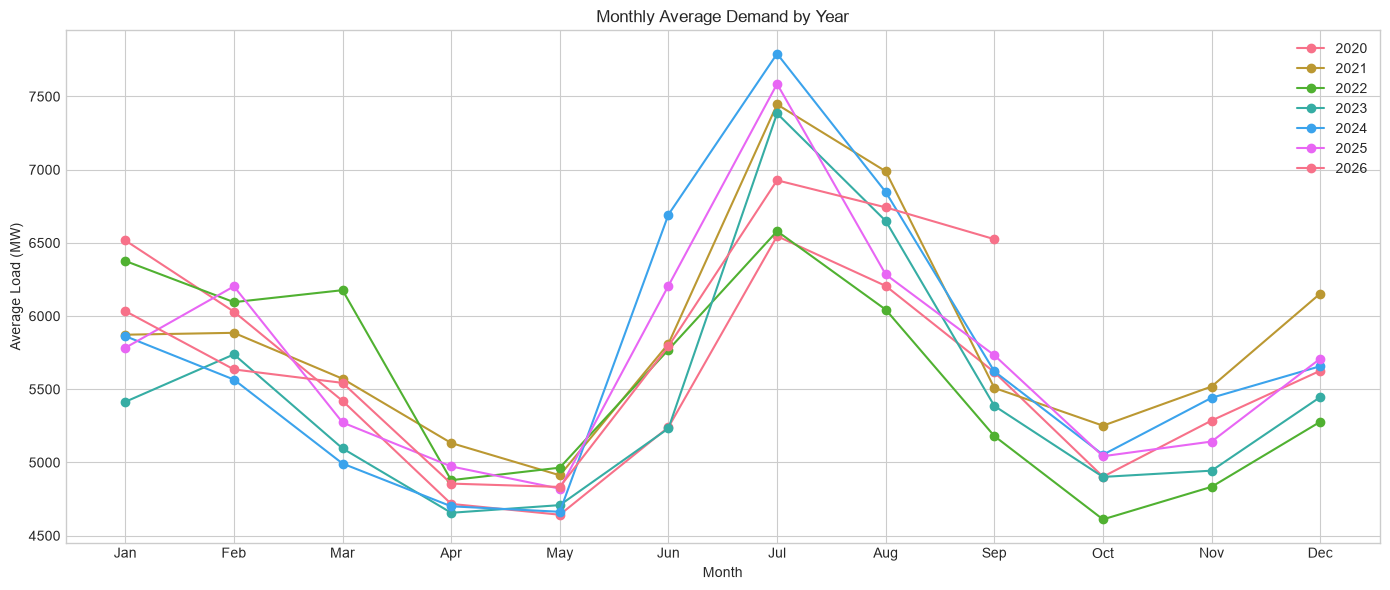

In [4]:
# Monthly average demand per year
df["year"] = df.timestamp.dt.year
df["month"] = df.timestamp.dt.month

monthly = df.groupby(["year", "month"])["actual_load_mw"].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 6))

for year in sorted(monthly.year.unique()):
    data = monthly[monthly.year == year]
    ax.plot(data.month, data.actual_load_mw, marker="o", label=str(year))

ax.set_xlabel("Month")
ax.set_ylabel("Average Load (MW)")
ax.set_title("Monthly Average Demand by Year")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                     "Jul","Aug","Sep","Oct","Nov","Dec"])
ax.legend()
plt.tight_layout()
plt.show()

## 4. Temperature vs Demand — The U-Shape

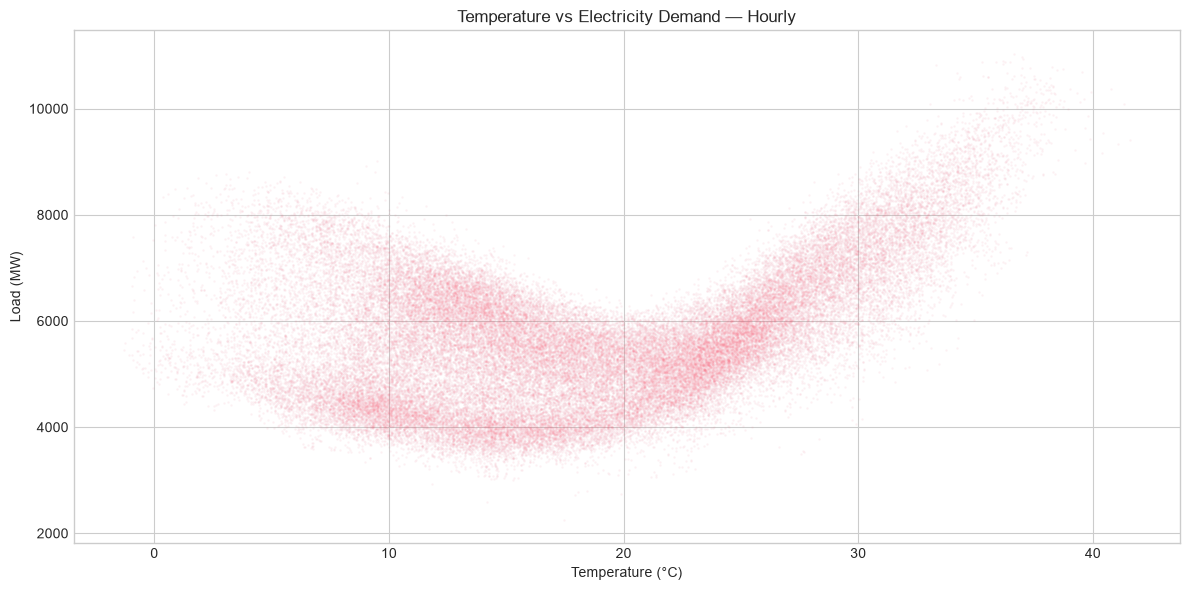

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(df.temperature_c, df.actual_load_mw, alpha=0.05, s=1)
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Load (MW)")
ax.set_title("Temperature vs Electricity Demand — Hourly")

plt.tight_layout()
plt.show()

## 5. Daily and Weekly Patterns

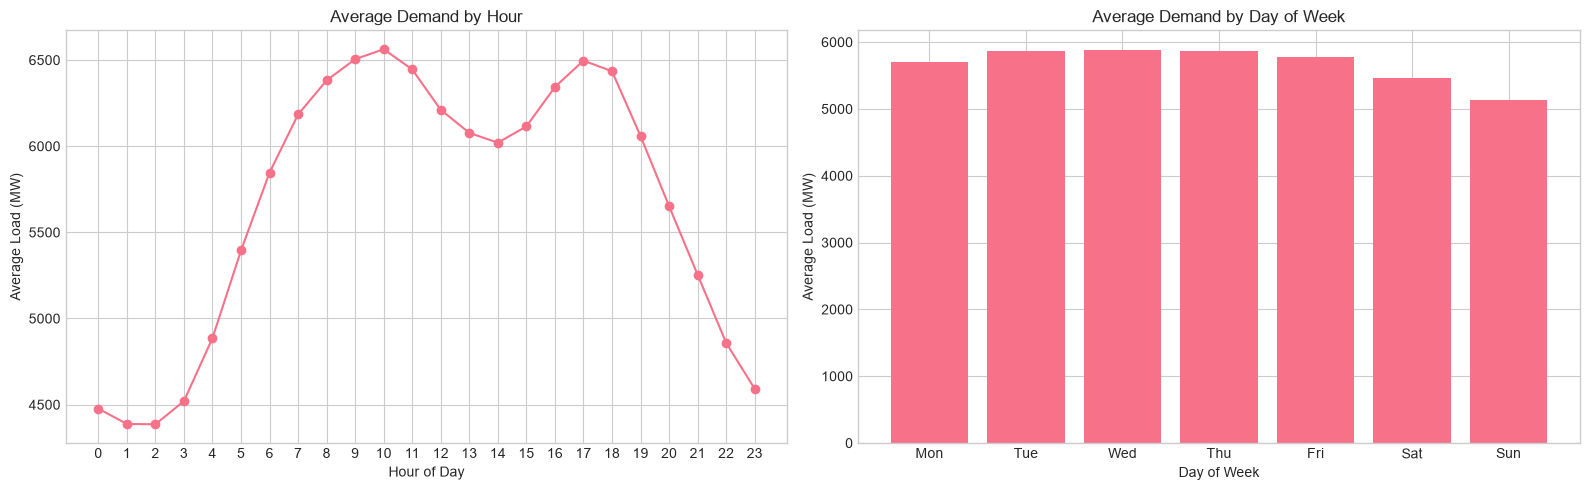

In [7]:
df["hour"] = df.timestamp.dt.hour
df["dayofweek"] = df.timestamp.dt.dayofweek  # 0=Monday, 6=Sunday

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Hourly pattern
hourly = df.groupby("hour")["actual_load_mw"].mean()
axes[0].plot(hourly.index, hourly.values, marker="o")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Average Load (MW)")
axes[0].set_title("Average Demand by Hour")
axes[0].set_xticks(range(0, 24))

# Weekly pattern
days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
daily = df.groupby("dayofweek")["actual_load_mw"].mean()
axes[1].bar(days, daily.values)
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Average Load (MW)")
axes[1].set_title("Average Demand by Day of Week")

plt.tight_layout()
plt.show()

## 6. ENTSO-E Benchmark — How Good Is the Day-Ahead Forecast?

=== ENTSO-E Day-Ahead Forecast Performance ===
MAE:  172 MW
RMSE: 241 MW
MAPE: 3.04%
Median Absolute Error: 123 MW


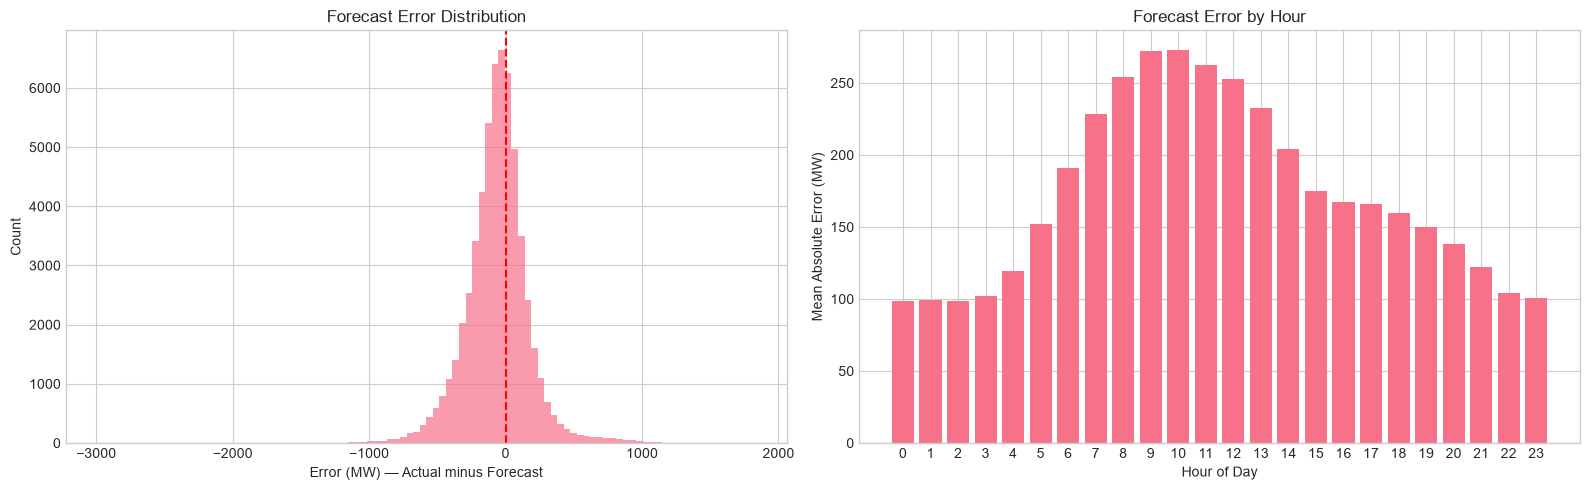

In [8]:
# Drop rows where forecast is missing
bench = df.dropna(subset=["forecast_load_mw"]).copy()

# Calculate errors
bench["error_mw"] = bench.actual_load_mw - bench.forecast_load_mw
bench["abs_error_mw"] = bench.error_mw.abs()
bench["pct_error"] = (bench.abs_error_mw / bench.actual_load_mw) * 100

print("=== ENTSO-E Day-Ahead Forecast Performance ===")
print(f"MAE:  {bench.abs_error_mw.mean():.0f} MW")
print(f"RMSE: {(bench.error_mw ** 2).mean() ** 0.5:.0f} MW")
print(f"MAPE: {bench.pct_error.mean():.2f}%")
print(f"Median Absolute Error: {bench.abs_error_mw.median():.0f} MW")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Error distribution
axes[0].hist(bench.error_mw, bins=100, edgecolor="none", alpha=0.7)
axes[0].axvline(x=0, color="red", linestyle="--")
axes[0].set_xlabel("Error (MW) — Actual minus Forecast")
axes[0].set_ylabel("Count")
axes[0].set_title("Forecast Error Distribution")

# Error by hour
hourly_error = bench.groupby("hour")["abs_error_mw"].mean()
axes[1].bar(hourly_error.index, hourly_error.values)
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Mean Absolute Error (MW)")
axes[1].set_title("Forecast Error by Hour")
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

## 7. Feature Correlations

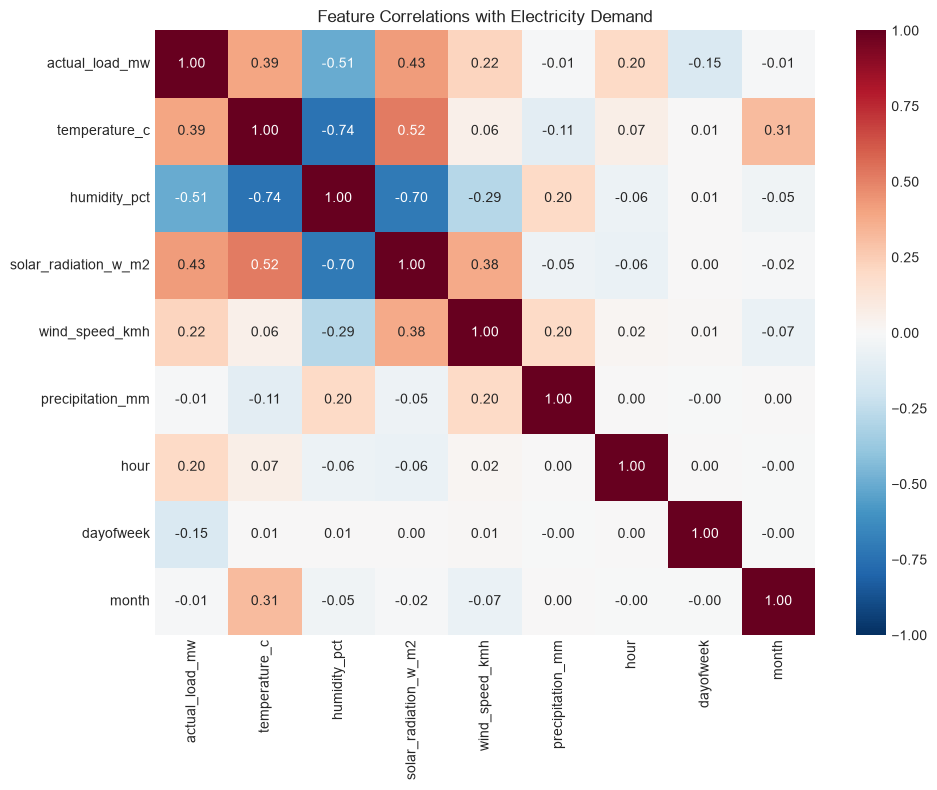

In [9]:
corr_cols = [
    "actual_load_mw", "temperature_c", "humidity_pct",
    "solar_radiation_w_m2", "wind_speed_kmh", "precipitation_mm",
    "hour", "dayofweek", "month"
]

corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="RdBu_r",
    center=0, vmin=-1, vmax=1, ax=ax
)
ax.set_title("Feature Correlations with Electricity Demand")
plt.tight_layout()
plt.show()

## 8. Key Findings — Summary

### Demand Patterns
- **Strong daily cycle**: low at 2-4 AM (~4,400 MW), peaks at 10-11 AM and 5-6 PM (~6,500 MW)
- **Weekly effect**: weekdays ~5,800 MW, Sunday ~5,100 MW (~14% drop)
- **Yearly seasonality**: summer peaks (AC) higher than winter peaks (heating)

### Weather–Demand Relationship
- **U-shaped** temperature dependency — demand rises at both extremes
- Linear correlation (0.39) understates the true relationship — need non-linear features
- Humidity (-0.51) and solar radiation (0.43) are strong predictors
- Wind speed (0.22) has moderate correlation

### ENTSO-E Benchmark
- **MAE: 172 MW, MAPE: 3.04%** — strong baseline to beat
- Worst performance during morning ramp (7-12 AM): ~270 MW error
- Best performance overnight (0-4 AM): ~100 MW error
- Morning ramp-up is our best opportunity to outperform

### Feature Engineering Implications
- Need **Heating Degree Days / Cooling Degree Days** (capture U-shape)
- Need **hour, day-of-week, month** features
- Need **lag features** (yesterday's demand at same hour)
- Consider **holiday calendar** for the Sunday-like dips